In [1]:
from pathlib import Path
from scipy.io import loadmat
import scipy.signal as sgn
import pandas as pd
import numpy as np
import re
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score


In [2]:
from Functions import remove_baseline_filter,  preprocess_one_file , stem_to_subject_id , prepare_split_data_loaders,training_curve_plot , WindowDataset, CNN1D, train_model_with_loaders, eval_loader_binary , run_one_experiment , select_channels

In [3]:

folder = Path(r"C:\Users\saber\thesis_second_try\data\Rest\Respiration_ECG_Raw")


# Parameters
FS_IN = 1000
FS_OUT = 60
WIN_LEN = 2048
STRIDE = WIN_LEN  # non-overlap
batch_size = 64

SIGNAL_ORDER = ["ECG_mV", "Fingerpulse", "Cannula", "Thermopod"]

SCALE = {
    "ECG_mV": 1000.0,      # V -> mV
    "Fingerpulse": 10.0,
    "Cannula": 10.0,
    "Thermopod": 1.0
}

# ────────────────────────────────────────────────
# The baseline function 
SOS = remove_baseline_filter(FS_IN)

#────────────────────────────────────────────────
# Run over alla the files
mat_files = sorted(folder.glob("*.mat"))
participant_files = [f for f in mat_files if f.name.startswith("resting_state_participant_")]
print("Total .mat files:", len(mat_files))
print("Participant files:", len(participant_files))

#────────────────────────────────────────────────
# Split the files in mouth and nose 
nose_files, mouth_files, skipped = [], [], []
for f in participant_files:
    m = re.search(r"participant_(\d+)", f.stem)
    if not m:
        skipped.append(f.name)
        continue
    pid = int(m.group(1))
    if 10 <= pid <= 112:
        nose_files.append(f)
    elif 200 <= pid <= 312:
        mouth_files.append(f)
    else:
        skipped.append(f.name)

print("Nose files :", len(nose_files))
print("Mouth files:", len(mouth_files))
print("Skipped    :", len(skipped))

#────────────────────────────────────────────────
# Preprocess each group 
nose_tensors_by_participant = {}
mouth_tensors_by_participant = {}
failed = []
# 1. for nose 
for f in nose_files:
    try:
        nose_tensors_by_participant[f.stem] = preprocess_one_file(
            f,
            fs_in=FS_IN,
            fs_out=FS_OUT,
            win_len=WIN_LEN,
            stride=STRIDE,
            keep_signals=SIGNAL_ORDER,
            scale=SCALE,
            sos=SOS,
        )
    except Exception as e:
        failed.append((f.name, "nose", str(e)))
# 2. for mouth
for f in mouth_files:
    try:
        mouth_tensors_by_participant[f.stem] = preprocess_one_file(
            f,
            fs_in=FS_IN,
            fs_out=FS_OUT,
            win_len=WIN_LEN,
            stride=STRIDE,
            keep_signals=SIGNAL_ORDER,
            scale=SCALE,
            sos=SOS,
        )
    except Exception as e:
        failed.append((f.name, "mouth", str(e)))

print("Processed nose :", len(nose_tensors_by_participant))
print("Processed mouth:", len(mouth_tensors_by_participant))
print("Failed:", len(failed))

#────────────────────────────────────────────────
# Stacking the tensors 
if len(nose_tensors_by_participant) > 0:
    nose_keys = sorted(nose_tensors_by_participant.keys())
    X_nose = np.stack([nose_tensors_by_participant[k] for k in nose_keys], axis=0)
    print("X_nose shape:", X_nose.shape)  # (P_nose, n_windows, 2, 2048)

if len(mouth_tensors_by_participant) > 0:
    mouth_keys = sorted(mouth_tensors_by_participant.keys())
    X_mouth = np.stack([mouth_tensors_by_participant[k] for k in mouth_keys], axis=0)
    print("X_mouth shape:", X_mouth.shape)  # (P_mouth, n_windows, 2, 2048)


Total .mat files: 207
Participant files: 205
Nose files : 102
Mouth files: 103
Skipped    : 0
Processed nose : 102
Processed mouth: 103
Failed: 0
X_nose shape: (102, 9, 4, 2048)
X_mouth shape: (103, 9, 4, 2048)


In [4]:
# Checking that everything is working
mouth_keys = sorted(mouth_tensors_by_participant.keys()) 
# print(mouth_keys)
print("X_mouth shape:", X_mouth .shape)
X_mouth = np.stack([mouth_tensors_by_participant[k] for k in mouth_keys], axis=0)
print("First 5 keys:", mouth_keys[:5])

X_mouth shape: (103, 9, 4, 2048)
First 5 keys: ['resting_state_participant_201', 'resting_state_participant_210', 'resting_state_participant_211', 'resting_state_participant_212', 'resting_state_participant_213']


In [5]:
import pandas as pd
Path_subject = r"df_mouth.csv"
df_mouth= pd.read_csv(Path_subject)
df_mouth.head()

,Subject Number,Gender,Age
0,1,1,27
1,10,1,37
2,11,1,29
3,12,0,25
4,13,0,31


In [6]:
age_by_subject = dict(zip(df_mouth["Subject Number"], df_mouth["Age"]))
age_by_subject # this is subject id and their correct gender 


{1: 27,
 10: 37,
 11: 29,
 12: 25,
 13: 31,
 14: 28,
 15: 25,
 16: 24,
 17: 18,
 18: 26,
 19: 26,
 20: 28,
 21: 24,
 22: 29,
 23: 33,
 24: 26,
 25: 31,
 26: 22,
 27: 27,
 28: 25,
 29: 23,
 30: 23,
 31: 23,
 32: 30,
 33: 28,
 34: 29,
 35: 19,
 36: 25,
 37: 35,
 38: 25,
 39: 38,
 40: 32,
 41: 30,
 42: 20,
 43: 36,
 44: 23,
 45: 29,
 46: 27,
 47: 41,
 48: 28,
 49: 20,
 50: 24,
 51: 23,
 52: 19,
 53: 28,
 54: 39,
 56: 42,
 57: 31,
 58: 26,
 59: 27,
 60: 32,
 61: 39,
 62: 33,
 63: 28,
 64: 28,
 65: 29,
 66: 24,
 67: 28,
 68: 30,
 69: 20,
 70: 24,
 71: 23,
 72: 19,
 73: 30,
 74: 22,
 75: 40,
 76: 28,
 77: 39,
 78: 30,
 79: 24,
 80: 24,
 81: 29,
 82: 26,
 83: 22,
 84: 19,
 85: 36,
 86: 35,
 87: 19,
 88: 42,
 89: 35,
 90: 32,
 91: 30,
 92: 27,
 93: 21,
 94: 39,
 95: 26,
 96: 33,
 97: 22,
 98: 33,
 99: 33,
 100: 31,
 101: 29,
 102: 38,
 103: 21,
 104: 24,
 105: 31,
 106: 27,
 107: 23,
 108: 25,
 109: 22,
 110: 34,
 111: 27,
 112: 27}

In [7]:
mouth_ids_from_files = np.array([stem_to_subject_id(k) for k in mouth_keys], dtype=int)

print("First 10 subject IDs from files:", mouth_ids_from_files[:10])
print("Number of participants from files:", len(mouth_ids_from_files))
print("Unique IDs:", len(np.unique(mouth_ids_from_files)))


mouth_ids_for_labels = mouth_ids_from_files - 200

print("First 10 raw mouth IDs:   ", mouth_ids_from_files[:10])
print("First 10 mapped label IDs:", mouth_ids_for_labels[:10])

y_mouth = np.array([age_by_subject[sid] for sid in mouth_ids_for_labels], dtype=int)
print("y_mouth age:", y_mouth)
print("y_mouth shape:", y_mouth.shape)


First 10 subject IDs from files: [201 210 211 212 213 214 215 216 217 218]
Number of participants from files: 103
Unique IDs: 103
First 10 raw mouth IDs:    [201 210 211 212 213 214 215 216 217 218]
First 10 mapped label IDs: [ 1 10 11 12 13 14 15 16 17 18]
y_mouth age: [27 37 29 25 31 28 25 24 18 26 26 28 24 29 33 26 31 22 27 25 23 23 23 30
 28 29 19 25 35 25 38 32 30 20 36 23 29 27 41 28 20 24 23 19 28 39 42 31
 26 27 32 39 33 28 28 29 24 28 30 20 24 23 19 30 22 40 28 39 30 24 24 29
 26 22 19 36 35 19 42 35 32 30 27 21 39 26 33 22 33 33 31 29 38 21 24 31
 27 23 25 22 34 27 27]
y_mouth shape: (103,)


In [8]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import numpy as np

def prepare_split_data_loaders(
    X_mouth, y_mouth,
    test_size=0.2,
    val_size=0.2,
    seed=6,
    batch_size=64,
    normalize=True,
    verbose=True,
    return_meta=True,
    task="regression",          # NEW: "classification" or "regression"
    stratify_bins=None,         # NEW: optional, e.g. [18,25,30,35,45]
):
    P, W, C, L = X_mouth.shape
    idx = np.arange(P)

    y_mouth = np.asarray(y_mouth)

    # --- choose stratify vector ---
    stratify_vec = None
    if task == "classification":
        stratify_vec = y_mouth
    elif task == "regression" and stratify_bins is not None:
        # stratify on bins (optional)
        bins = np.asarray(stratify_bins)
        # digitize returns bin ids; good for stratify *if* bins have enough samples
        stratify_vec = np.digitize(y_mouth, bins=bins, right=True)

    if verbose:
        print("X_mouth:".ljust(12), X_mouth.shape)
        print("y_mouth:".ljust(12), y_mouth.shape,
              "  min/max:", float(np.min(y_mouth)), float(np.max(y_mouth)))

        if stratify_vec is not None:
            u, c = np.unique(stratify_vec, return_counts=True)
            print("Stratify bins/classes counts:", dict(zip(u.tolist(), c.tolist())))

    # 1) split test vs train+val
    trainval_idx, test_idx = train_test_split(
        idx,
        test_size=test_size,
        random_state=seed,
        stratify=stratify_vec
    )

    # 2) split train vs val
    stratify_vec_trainval = None if stratify_vec is None else stratify_vec[trainval_idx]

    train_idx, val_idx = train_test_split(
        trainval_idx,
        test_size=val_size,
        random_state=seed + 1,
        stratify=stratify_vec_trainval
    )

    # participant-level splits
    X_train_p, y_train_p = X_mouth[train_idx], y_mouth[train_idx]
    X_val_p,   y_val_p   = X_mouth[val_idx],   y_mouth[val_idx]
    X_test_p,  y_test_p  = X_mouth[test_idx],  y_mouth[test_idx]

    mu = sd = None
    if normalize:
        mu = X_train_p.mean(axis=(0, 1, 3), keepdims=True)
        sd = X_train_p.std(axis=(0, 1, 3), keepdims=True) + 1e-8

        X_train_p = (X_train_p - mu) / sd
        X_val_p   = (X_val_p   - mu) / sd
        X_test_p  = (X_test_p  - mu) / sd

        if verbose:
            print("\nAfter normalization (train mean per ch):", X_train_p.mean(axis=(0,1,3)))
            print("After normalization (train std  per ch):", X_train_p.std(axis=(0,1,3)))

    # window-level
    X_train = X_train_p.reshape(len(train_idx) * W, C, L)
    y_train = np.repeat(y_train_p, W)

    X_val   = X_val_p.reshape(len(val_idx) * W, C, L)
    y_val   = np.repeat(y_val_p, W)

    X_test  = X_test_p.reshape(len(test_idx) * W, C, L)
    y_test  = np.repeat(y_test_p, W)

    if verbose:
        print("\nWindow-level shapes:")
        print("X_train:".ljust(12), X_train.shape, " y_train:", y_train.shape)
        print("X_val  :".ljust(12), X_val.shape,   " y_val  :", y_val.shape)
        print("X_test :".ljust(12), X_test.shape,  " y_test :", y_test.shape)

    train_loader = DataLoader(WindowDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(WindowDataset(X_val,   y_val),   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(WindowDataset(X_test,  y_test),  batch_size=batch_size, shuffle=False)

    if not return_meta:
        return train_loader, val_loader, test_loader

    meta = {
        "P": P, "W": W, "C": C, "L": L,
        "seed": seed,
        "train_idx": train_idx, "val_idx": val_idx, "test_idx": test_idx,
        "X_train_p": X_train_p, "y_train_p": y_train_p,
        "X_val_p": X_val_p, "y_val_p": y_val_p,
        "X_test_p": X_test_p, "y_test_p": y_test_p,
        "X_train": X_train, "y_train": y_train,
        "X_val": X_val, "y_val": y_val,
        "X_test": X_test, "y_test": y_test,
        "mu": mu, "sd": sd,
    }

    return train_loader, val_loader, test_loader, meta

In [9]:

train_loader, val_loader, test_loader, meta = prepare_split_data_loaders(
    X_mouth, y_mouth,
    seed=6,
    batch_size=batch_size,
    normalize=True,
    return_meta=True,
    task="regression"
)
# baseline: 
X_val_p = meta["X_val_p"]
y_val_p = meta["y_val_p"].astype(float)
baseline_mean = float(np.mean(y_val_p))
baseline_mae = float(np.mean(np.abs(y_val_p - baseline_mean)))
print("Baseline mean-age:", baseline_mean)
print("Baseline MAE (mean predictor):", baseline_mae)
# ────────────────────────────────────────────────
#  Quick sanity checks on test set 

print("\nFirst 20 test window labels:", meta['y_train'][10:40])

print("Example test window [0] – channel means:", meta['X_test'][0].mean(axis=1))

# If you want to see beginning of first channel of first test window:
print("Example test window[0] channel 0 – first 30 values:")
print(meta['X_test'][0, 0, :30])

X_mouth:     (103, 9, 4, 2048)
y_mouth:     (103,)   min/max: 18.0 42.0

After normalization (train mean per ch): [-1.8387651e-10  1.3749943e-09 -3.5561398e-10 -2.6260112e-09]
After normalization (train std  per ch): [1.0000002 0.9999998 1.0000001 1.0000001]

Window-level shapes:
X_train:     (585, 4, 2048)  y_train: (585,)
X_val  :     (153, 4, 2048)  y_val  : (153,)
X_test :     (189, 4, 2048)  y_test : (189,)
Baseline mean-age: 26.470588235294116
Baseline MAE (mean predictor): 4.0276816608996535

First 20 test window labels: [28 28 28 28 28 28 28 28 22 22 22 22 22 22 22 22 22 28 28 28 28 28 28 28
 28 28 23 23 23 23]
Example test window [0] – channel means: [ 0.00048972 -0.00194028 -0.00212743 -0.00012808]
Example test window[0] channel 0 – first 30 values:
[ 0.26361603  0.59141344  0.17453033  0.03537316 -0.1214521  -0.37192205
 -0.0816318  -0.63851047  0.47228858  3.8804483  -0.634144   -0.8710825
 -0.16873902 -0.13624139 -0.11546018 -0.06248597  0.01225171  0.04551703
  0.16582027

In [10]:
import torch
import torch.nn as nn

class CNN1DRegressor(nn.Module):
    def __init__(self, n_channels: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),  # -> [B, 128, 1]
        )
        self.head = nn.Linear(128, 1)  # ONE number = predicted age

    def forward(self, x):
        # x: [B, C, L]
        z = self.features(x).squeeze(-1)   # [B, 128]
        y_hat = self.head(z).squeeze(1)    # [B]
        return y_hat  # <-- NOT logits and just a number 
    
model = CNN1DRegressor(len(SIGNAL_ORDER))

In [11]:
import time
import numpy as np
import torch
import torch.nn as nn

def train_model_with_loaders_regression(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=1e-3,
    patience=10,
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    # TODO: WHICH ONE TO CHOOSE?
    # criterion = nn.MSELoss()   # MSE
    criterion = nn.L1Loss()  # MAE directly

    trL, vaL = [], []
    trMAE, vaMAE = [], []

    best_val = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        # ---- train ----
        model.train()
        train_losses = []
        y_true_tr, y_pred_tr = [], []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.float().to(device)

            optimizer.zero_grad()
            y_hat = model(xb).squeeze()          # [B]
            loss = criterion(y_hat, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            y_true_tr.append(yb.detach().cpu().numpy())
            y_pred_tr.append(y_hat.detach().cpu().numpy())

        y_true_tr = np.concatenate(y_true_tr)
        y_pred_tr = np.concatenate(y_pred_tr)
        train_mae = float(np.mean(np.abs(y_true_tr - y_pred_tr)))

        trL.append(float(np.mean(train_losses)))
        trMAE.append(train_mae)

        # ---- val ----
        model.eval()
        val_losses = []
        y_true_va, y_pred_va = [], []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.float().to(device)

                y_hat = model(xb).squeeze()
                loss = criterion(y_hat, yb)

                val_losses.append(loss.item())
                y_true_va.append(yb.cpu().numpy())
                y_pred_va.append(y_hat.cpu().numpy())

        y_true_va = np.concatenate(y_true_va)
        y_pred_va = np.concatenate(y_pred_va)
        val_mae = float(np.mean(np.abs(y_true_va - y_pred_va)))

        vaL.append(float(np.mean(val_losses)))
        vaMAE.append(val_mae)

        print(f"Epoch {epoch:02d} | train_loss={trL[-1]:.4f} val_loss={vaL[-1]:.4f} "
              f"| train_MAE={train_mae:.2f}y val_MAE={val_mae:.2f}y")

        # ---- early stopping on val_loss (or val_MAE if you prefer) ----
        if vaL[-1] < best_val:
            best_val = vaL[-1]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping at epoch {epoch} (best val_loss={best_val:.4f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, trL, vaL, trMAE, vaMAE

In [12]:
Epochs = 50
lr = 1e-3
patience = 10

model = CNN1DRegressor(len(SIGNAL_ORDER))

t0 = time.time()
model, trL, vaL, trMAE, vaMAE = train_model_with_loaders_regression(
    model,
    train_loader,
    val_loader,
    epochs=Epochs,
    lr=lr,
    patience=patience,
)
t1 = time.time()

print("Final train MAE (years):", trMAE[-1])
print("Final val   MAE (years):", vaMAE[-1])

Epoch 01 | train_loss=26.7721 val_loss=24.2764 | train_MAE=26.92y val_MAE=24.00y
Epoch 02 | train_loss=20.6694 val_loss=12.8358 | train_MAE=21.13y val_MAE=12.35y
Epoch 03 | train_loss=9.5325 val_loss=8.1639 | train_MAE=9.73y val_MAE=9.53y
Epoch 04 | train_loss=8.4092 val_loss=8.2856 | train_MAE=8.44y val_MAE=8.20y
Epoch 05 | train_loss=7.4679 val_loss=6.7272 | train_MAE=7.50y val_MAE=7.43y
Epoch 06 | train_loss=6.9904 val_loss=6.6769 | train_MAE=6.94y val_MAE=7.05y
Epoch 07 | train_loss=6.6846 val_loss=6.4022 | train_MAE=6.67y val_MAE=6.86y
Epoch 08 | train_loss=6.3306 val_loss=6.3385 | train_MAE=6.50y val_MAE=6.64y
Epoch 09 | train_loss=6.2670 val_loss=6.0887 | train_MAE=6.29y val_MAE=6.63y
Epoch 10 | train_loss=6.0016 val_loss=6.0589 | train_MAE=6.17y val_MAE=6.35y
Epoch 11 | train_loss=6.0222 val_loss=5.8931 | train_MAE=6.02y val_MAE=6.30y
Epoch 12 | train_loss=6.0302 val_loss=5.7763 | train_MAE=5.96y val_MAE=6.24y
Epoch 13 | train_loss=5.7593 val_loss=5.7646 | train_MAE=5.86y val_M

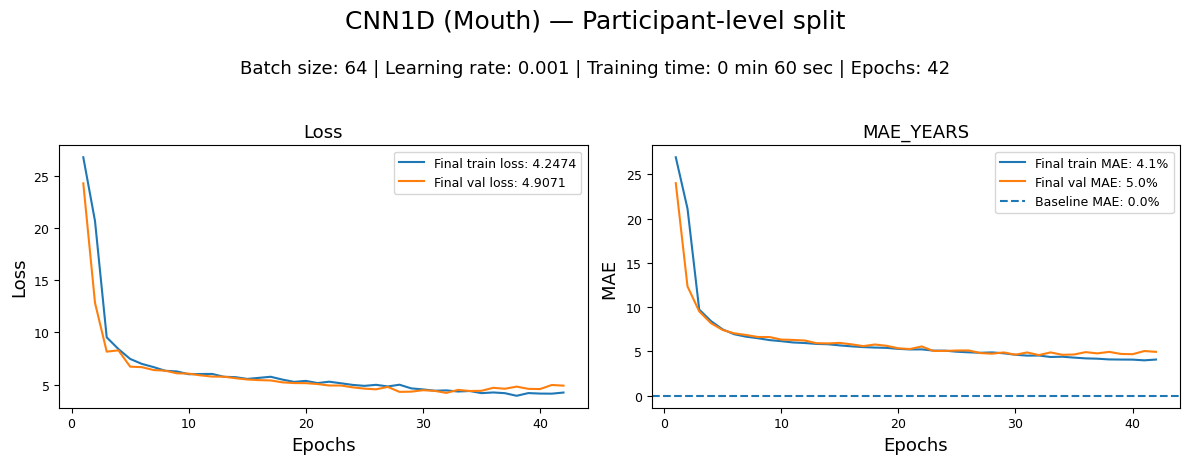

In [13]:

def training_curve_plot(
    title,
    train_losses,
    val_losses,
    train_accs,
    val_accs,
    batch_size=None,
    learning_rate=None,
    training_time=None,
    baseline_acc=None 
):
    lg, md, sm = 18, 13, 9

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, y=1.15, fontsize=lg)

    info = []
    if batch_size is not None:
        info.append(f"Batch size: {batch_size}")
    if learning_rate is not None:
        info.append(f"Learning rate: {learning_rate}")
    if training_time is not None:
        mins, secs = divmod(training_time, 60)
        info.append(f"Training time: {int(mins)} min {secs:.0f} sec")
    info.append(f"Epochs: {len(train_losses)}")
    fig.text(0.5, 0.99, " | ".join(info), ha='center', fontsize=md)

    x = range(1, len(train_losses) + 1)

    axs[0].plot(x, train_losses, label=f"Final train loss: {train_losses[-1]:.4f}")
    axs[0].plot(x, val_losses, label=f"Final val loss: {val_losses[-1]:.4f}")
    axs[0].set_title("Loss", fontsize=md)
    axs[0].set_xlabel("Epochs", fontsize=md)
    axs[0].set_ylabel("Loss", fontsize=md)
    axs[0].legend(fontsize=sm)
    axs[0].tick_params(axis='both', labelsize=sm)

    train_accs = np.array(train_accs) 
    val_accs   = np.array(val_accs) 

    axs[1].plot(x, train_accs, label=f"Final train MAE: {train_accs[-1]:.1f}%")
    axs[1].plot(x, val_accs, label=f"Final val MAE: {val_accs[-1]:.1f}%")

    if baseline_acc is not None:
        axs[1].axhline(baseline_acc * 100, linestyle="--",
                       label=f"Baseline MAE: {baseline_acc*100:.1f}%")

    axs[1].set_title("MAE_YEARS", fontsize=md)
    axs[1].set_xlabel("Epochs", fontsize=md)
    axs[1].set_ylabel("MAE ", fontsize=md)
    axs[1].legend(fontsize=sm)
    axs[1].tick_params(axis='both', labelsize=sm)

    plt.tight_layout()
    plt.show()


training_curve_plot(
    title="CNN1D (Mouth) — Participant-level split",
    train_losses=trL,
    val_losses=vaL,
    train_accs=trMAE,
    val_accs=vaMAE,
    batch_size=64,
    learning_rate=0.001,
    training_time=(t1 - t0),
    baseline_acc=0
)



In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import torch
def evaluate_window_level(model, test_loader, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)

    y_true, y_pred = [], []

    with torch.no_grad():
        for xb, age in test_loader:
            xb = xb.to(device)
            age = age.float().to(device)

            y_hat = model(xb).squeeze()

            y_true.append(age.cpu().numpy())
            y_pred.append(y_hat.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"Window-level MAE:  {mae:.2f} years")
    print(f"Window-level RMSE: {rmse:.2f} years")
    print(f"Window-level R2:   {r2:.3f}")

    return mae, rmse, r2, y_true, y_pred

In [15]:
mae, rmse, r2, y_true, y_pred = evaluate_window_level(model, test_loader)

print("First 20 true ages:", y_true[:20])
print("First 20 predicted ages:", y_pred[:20])

Window-level MAE:  6.12 years
Window-level RMSE: 7.45 years
Window-level R2:   -0.539
First 20 true ages: [27. 27. 27. 27. 27. 27. 27. 27. 27. 31. 31. 31. 31. 31. 31. 31. 31. 31.
 38. 38.]
First 20 predicted ages: [26.625168 25.883224 26.42157  25.010017 26.45665  26.591316 26.67984
 26.216648 27.52435  24.052046 24.721516 23.915232 24.52046  24.625883
 24.399208 24.22052  24.529594 24.60006  26.32126  26.662605]


todo 
1. create a plot regression 
2. mean avergae age create a base line

In [26]:
print(np.unique(y_true))
print(np.unique(y_pred))
y_pred_int = np.round(y_pred)
print(np.unique(y_pred_int))

[22. 23. 24. 25. 27. 28. 29. 30. 31. 33. 34. 36. 38. 39. 41. 42.]
[23.714336 23.893505 23.915232 23.961414 23.980507 24.009356 24.052046
 24.109043 24.22052  24.242102 24.3141   24.380272 24.399208 24.472374
 24.488192 24.52046  24.529594 24.53487  24.548836 24.564823 24.599955
 24.60006  24.611609 24.625883 24.681051 24.689259 24.717262 24.721516
 24.751236 24.819498 24.84744  24.96188  25.001762 25.010017 25.027355
 25.048313 25.062754 25.08464  25.169918 25.19551  25.229893 25.255405
 25.276794 25.287209 25.287964 25.289772 25.320286 25.368256 25.372633
 25.38343  25.45819  25.471378 25.480387 25.545654 25.581469 25.616907
 25.626606 25.627354 25.627995 25.663822 25.686451 25.696428 25.735197
 25.745232 25.760838 25.77097  25.784748 25.798153 25.883224 25.903103
 25.925274 25.934254 25.988075 25.994617 26.001167 26.025959 26.06023
 26.107754 26.129944 26.137592 26.163555 26.180363 26.216648 26.240229
 26.27197  26.278603 26.297348 26.313747 26.32126  26.336374 26.349287
 26.36525  2

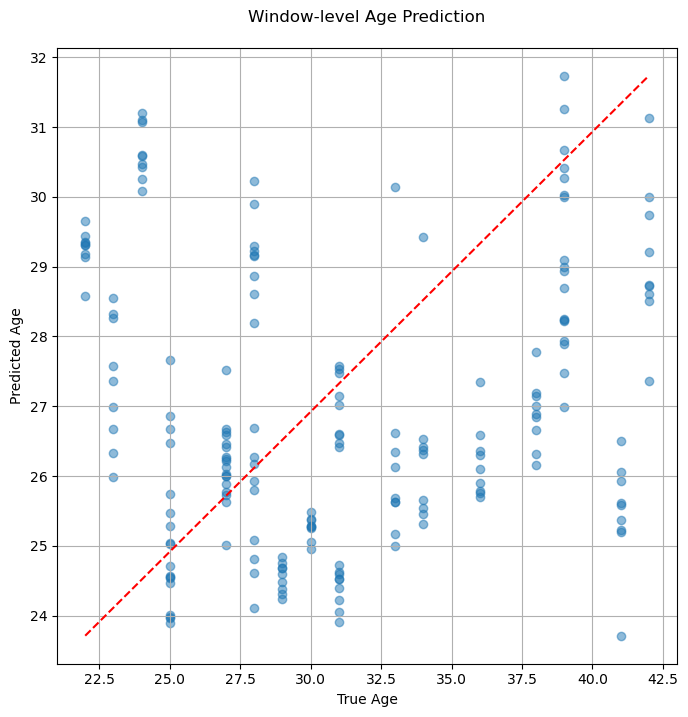

In [32]:
plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.5)

plt.plot([y_true.min(), y_true.max()], [y_pred.min(), y_pred.max()], 'r--')
plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title(f"Window-level Age Prediction\n")

plt.grid(True)
plt.show()

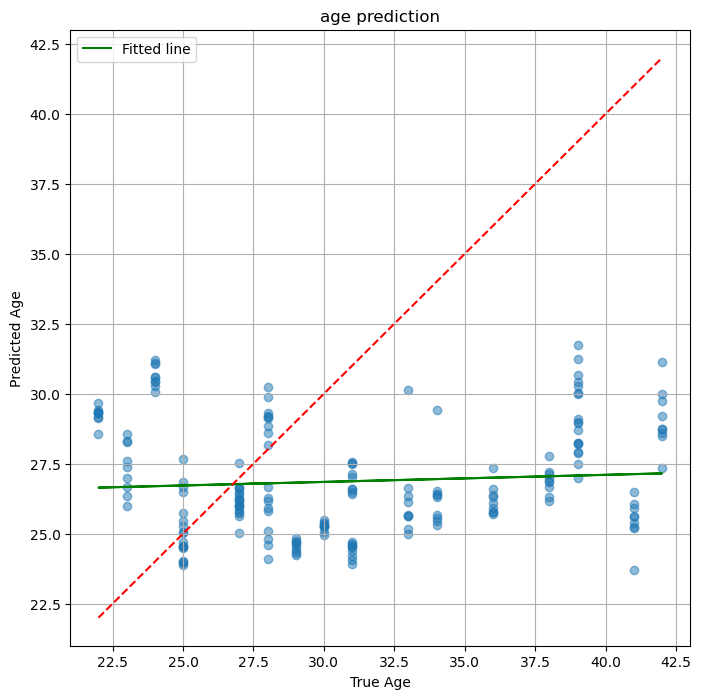

In [34]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

x = y_true
y = y_pred
# https://www.w3schools.com/python/python_ml_linear_regression.asp
slope, intercept, r, p, std_err = stats.linregress(x, y)

def myfunc(x):
    return slope * x + intercept

mymodel = myfunc(x)

plt.figure(figsize=(8,8))
plt.scatter(x, y, alpha=0.5)
plt.plot(x, mymodel, color="green", label="Fitted line")


plt.plot([x.min(), x.max()], [x.min(), x.max()], 'r--')

plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title(f"age prediction")

plt.legend()
plt.grid(True)
plt.show()

I rounded up the values so we dont 

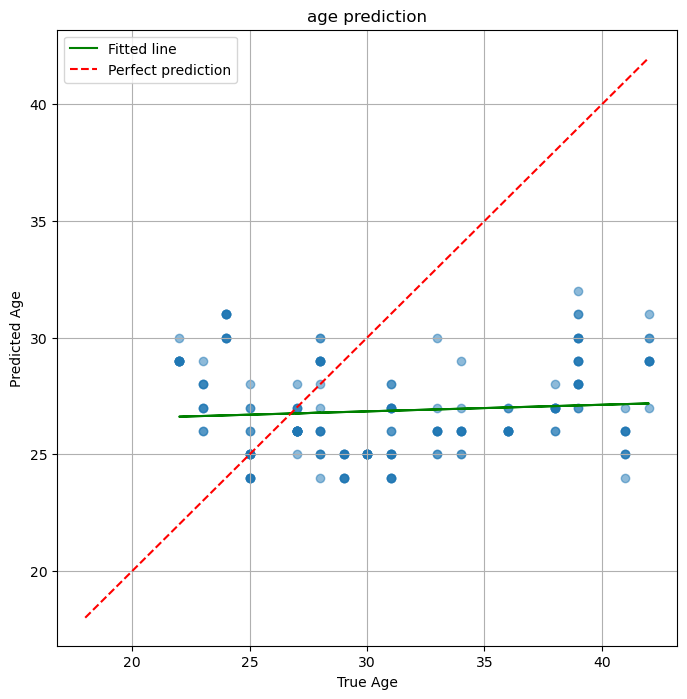

In [27]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

x = y_true
y = y_pred_int
# https://www.w3schools.com/python/python_ml_linear_regression.asp
slope, intercept, r, p, std_err = stats.linregress(x, y)

def myfunc(x):
    return slope * x + intercept

mymodel = myfunc(x)

plt.figure(figsize=(8,8))
plt.scatter(x, y, alpha=0.5)
plt.plot(x, mymodel, color="green", label="Fitted line")


plt.plot([18, 42], [18, 42], "r--", label="Perfect prediction")

plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title(f"age prediction")

plt.legend()
plt.grid(True)
plt.show()